In [10]:
import confnotebook

In [11]:
from pathlib import Path

source = Path("../examples/test/bag_15062026")

files = sorted(source.glob("*.pdf"))

for i, file in enumerate(files):
    print(f"[{i}] {file.stem}")

[0] 000-591590 2024 Р±РЅ
[1] 000-591590 2025 Р±РЅ
[2] 000-591590 2026 Р±РЅ
[3] 04062001scan
[4] 1 квартал 2026
[5] 113130_Черно-бел. док-т_04062026
[6] 20260604scan150446
[7] 3 кв. 2025
[8] Scan_0034
[9] scan_20010116015111
[10] АС АО КУРГАНМАШЗАВОД
[11] АС РБ за 2025 г
[12] АС СУЭК апрель 26
[13] АСВ Лоста на 31.03.
[14] Акт Сверки РУСАЛ Ачинск
[15] Акт сверки 01012026-31032026
[16] Акт сверки 2025 от 16.04.2026 (1)
[17] Акт сверки 2026 от 16.04.2026
[18] Акт сверки взаиморасчетов № 05800004074 от 29 мая 2026 г
[19] Акт сверки взаиморасчетов № 102 от 03 июня 2026 г
[20] Акт сверки взаиморасчетов № 151 от 20 мая 2026 г без 9_10 этапа
[21] Акт сверки взаиморасчетов № 6171 от 02 июня 2026 г
[22] Акт сверки май 2026
[23] Акт сверки янв-мар 2026 (подпись К-ПМ)
[24] Акт сверки №1523 от 21.04.26 - 5f1bfca4-fde6-48ac-93cd-9266c8fa14d2
[25] Акт сверки №И--000238 от 06.04.26 РИТС
[26] Акт сверки
[27] Альфа-Металл
[28] БАЙКАЛ АКВА Акт сверки 2025-2026.05.28 от КП Крокус (002)
[29] Байкал Аква 23

In [12]:
IDX_FILE = 23

In [13]:
from vision_core.loader.pdf_loader import PDFLoader

img = PDFLoader(pdf_bytes=files[IDX_FILE].read_bytes()).get_page_image(page_num=0, dpi=200)

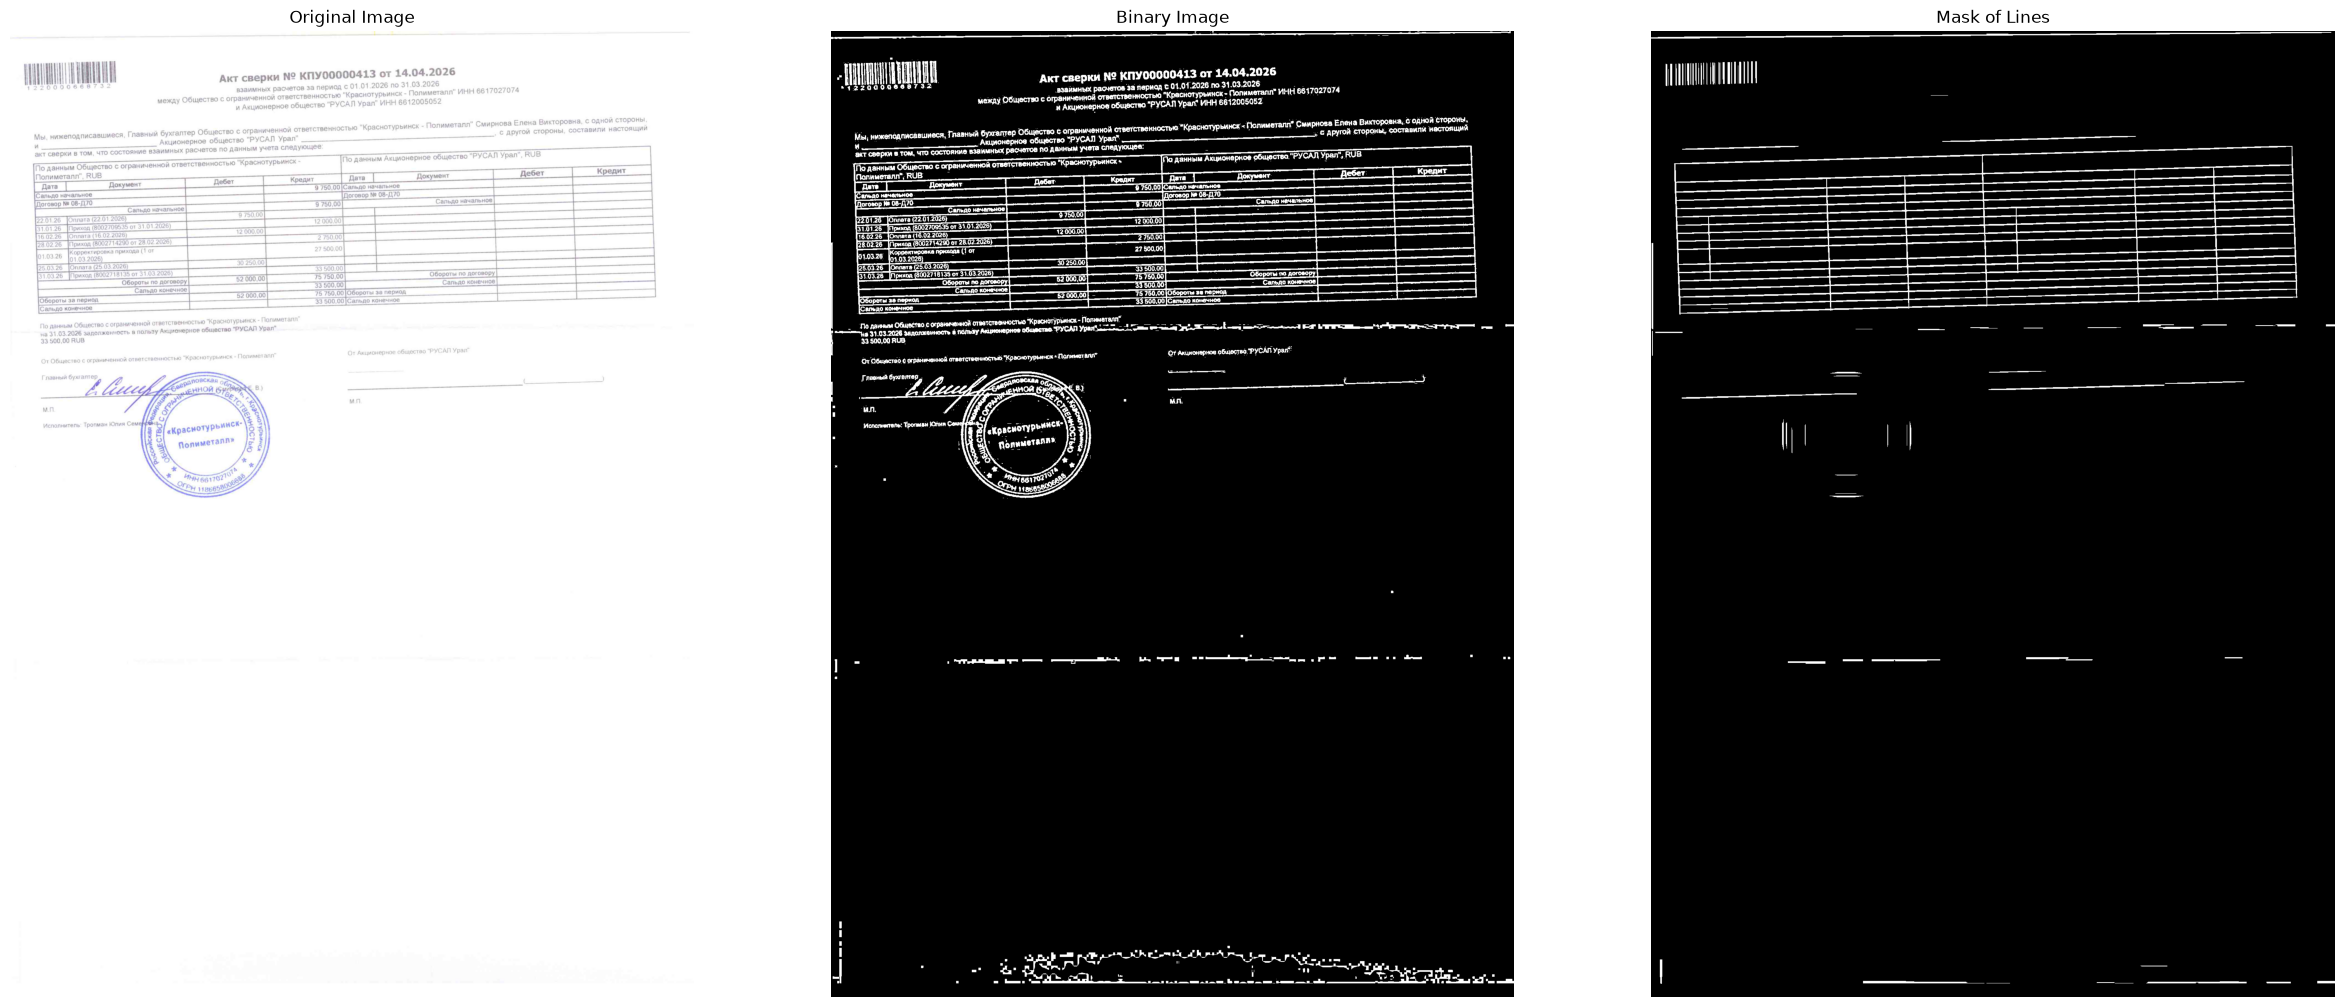

In [14]:
import cv2  # noqa: I001
import matplotlib.pyplot as plt
import numpy as np
from vision_core.utils import geometry_utils, image_utils
from vision_core.entities.bbox import BBox

gamma_img = image_utils.gamma_correction(img, gamma=10.0)
bin_img = image_utils.binary_threshold(gamma_img, block_size=15, C=5)


h_line_mask = image_utils.compute_horizontal_line_mask(bin_img, scale=40)
v_line_mask = image_utils.compute_vertical_line_mask(bin_img, median_height=40)
table_mask = image_utils.get_mask(h_line_mask, v_line_mask)

def extract_raw_tables(
    table_mask: np.ndarray,
    border_tol: int = 8,
    scale_width: float = 0.35,
    scale_height: float = 0.08,
    min_density: float = 0.01,
    intersection_over_min_thr: float = 0.2,
) -> list[BBox]:
    """Извлекает bounding boxes таблиц из маски таблицы.

    Args:
        table_mask: Бинарная маска, где белые пиксели соответствуют линиям таблицы.
        border_tol: Толерантность к границам изображения в пикселях. Таблицы, касающиеся границ, будут отфильтрованы.
        scale_width: Минимальная ширина таблицы относительно ширины изображения для фильтрации
        scale_height: Минимальная высота таблицы относительно ширины изображения для фильтрации
        min_density: Минимальная плотность белых пикселей внутри bounding box для таблиц, касающихся границ
        intersection_over_min_thr: Порог для объединения перекрывающихся bounding boxes (IoM > threshold)
    Returns:
        list[BBox]: Список bounding boxes таблиц, представленных в виде объектов BBox.
    """
    contours = geometry_utils.find_contours(table_mask)
    candidates: list[tuple[int, int, int, int]] = []
    H, W = table_mask.shape[:2]
    min_width = int(W * scale_width)
    min_height = int(H * scale_height)

    for contour in contours:
        x, y, w, h = geometry_utils.bounding_rect(contour)

        if w < min_width or h < min_height:
            continue

        if w > W * 0.95 and h > H * 0.95:
            continue

        touches_border = x <= border_tol or y <= border_tol or x + w >= W - border_tol or y + h >= H - border_tol
        density = geometry_utils.count_non_zero_pixels(geometry_utils.roi_from_xywh(table_mask, (x, y, w, h)))

        if touches_border and density < min_density:
            continue

        candidates.append((x, y, w, h))

    bboxes: list[BBox] = []
    for x, y, w, h in candidates:
        box = BBox(x_min=x, y_min=y, x_max=x + w, y_max=y + h)
        if any(
            kept.contains(box) or box.contains(kept) or kept.intersection_over_min(box) > intersection_over_min_thr
            for kept in bboxes
        ):
            continue
        bboxes.append(box)

    return bboxes

plt.figure(figsize=(30, 20))
plt.subplot(1, 3, 1)
plt.imshow(img)
plt.title("Original Image")
plt.axis("off")
plt.subplot(1, 3, 2)
plt.imshow(bin_img, cmap="gray")
plt.title("Binary Image")
plt.axis("off")
plt.subplot(1, 3, 3)
plt.imshow(table_mask, cmap="gray")
plt.title("Mask of Lines")
plt.axis("off")
plt.show()

[BBox(x_min=55.0, y_min=278.0, x_max=1566.0, y_max=687.0)]


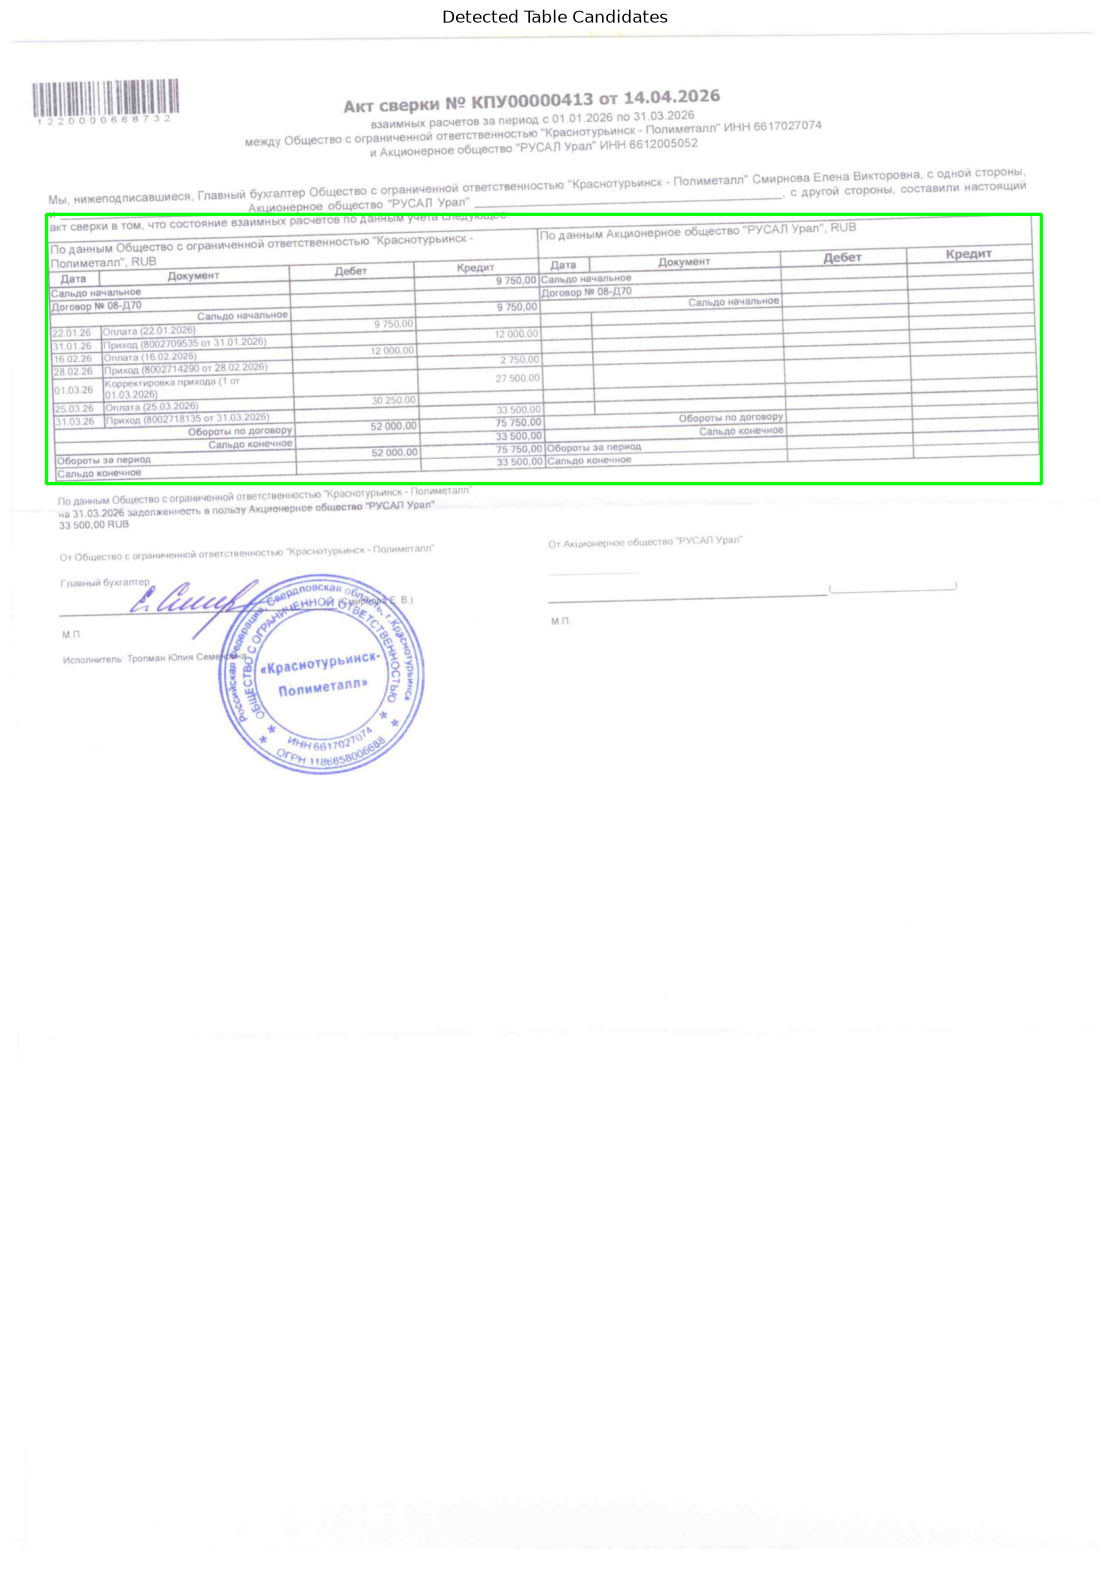

In [15]:
bboxes = extract_raw_tables(table_mask)
print(bboxes)
debug_img = img.copy()

for bbox in bboxes:
    x, y, w, h = bbox.to_tuple()
    cv2.rectangle(debug_img, (x, y), (w, h), (0, 255, 0), 3)

plt.figure(figsize=(30, 20))
plt.imshow(debug_img)
plt.title("Detected Table Candidates")
plt.axis("off")
plt.show()
 

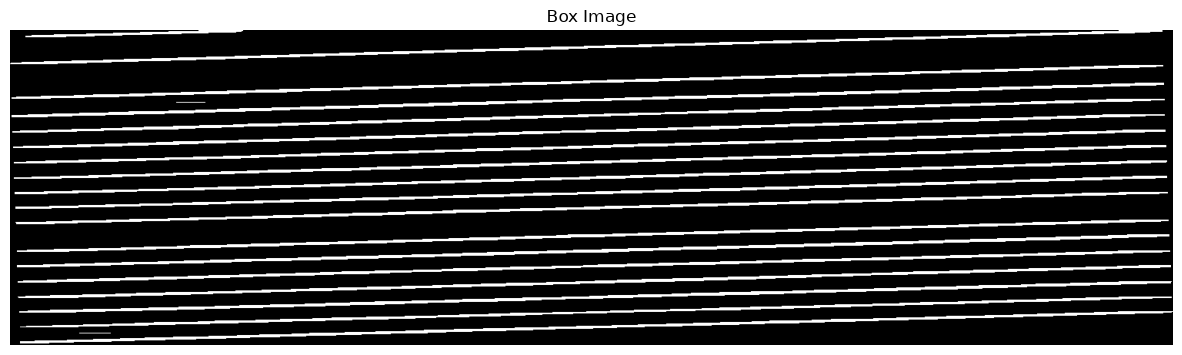

In [16]:
for bbox in bboxes:
    x, y, w, h = bbox.to_tuple()
    box_img = bbox.roi(bin_img)

    mask = image_utils.compute_horizontal_line_mask(box_img, scale=40)

    plt.figure(figsize=(15, 10))
    plt.imshow(mask, cmap="gray")
    plt.title("Box Image")
    plt.axis("off")

[-1.6320721 -1.6260941 -1.6209544 -1.6429757 -1.6512625 -1.6271012
 -1.6313884 -1.616098  -1.5627753 -1.5509242 -1.5696892 -1.5537475
 -1.5436598 -1.5852582 -1.5252445 -1.5124854 -1.5352756]
Estimated skew angle: -1.585 degrees
Used components: 17


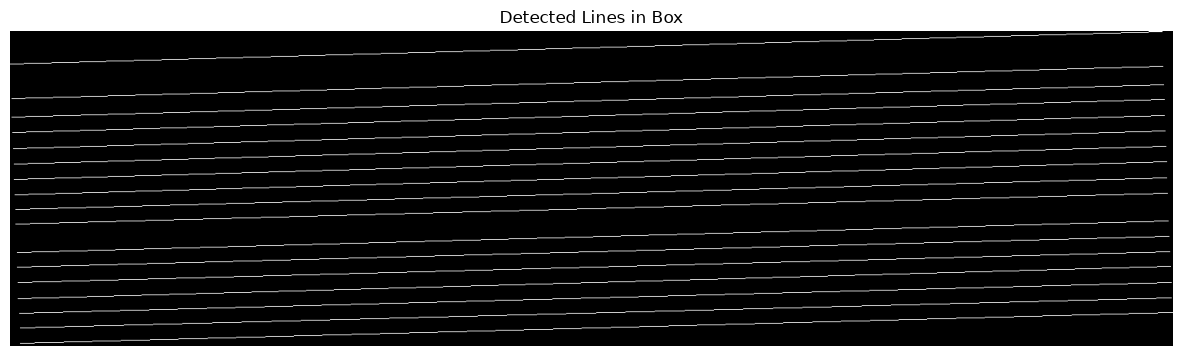

In [17]:
def _normalize_angle_deg(angle: float) -> float:
    if angle > 90:
        angle -= 180
    if angle < -90:
        angle += 180
    return angle


def _weighted_median(values: np.ndarray, weights: np.ndarray) -> float:
    order = np.argsort(values)
    values = values[order]
    weights = weights[order]
    csum = np.cumsum(weights)
    idx = np.searchsorted(csum, 0.5 * csum[-1])
    return float(values[min(idx, len(values) - 1)])


all_angles: list[float] = []
all_weights: list[float] = []
debug_masks: list[np.ndarray] = []

for bbox in bboxes:
    box_bin = bbox.roi(bin_img)
    mask = image_utils.compute_horizontal_line_mask(box_bin, scale=40)

    num, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
    d_mask = np.zeros_like(mask)

    for lbl in range(1, num):


        comp = (labels == lbl).astype(np.uint8) * 255
        cnts, _ = cv2.findContours(comp, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)

        if not cnts:
            continue

        cnt = max(cnts, key=cv2.contourArea)
        x, y, bw, bh = cv2.boundingRect(cnt)
        if bw < bbox.width * 0.6:
            continue

        vx, vy, x0, y0 = cv2.fitLine(cnt, cv2.DIST_L2, 0, 0.01, 0.01).reshape(-1)
        angle = _normalize_angle_deg(float(np.degrees(np.arctan2(vy, vx))))

        x_pts = cnt[:, 0, 0]
        x1, x2 = int(x_pts.min()), int(x_pts.max())
        if abs(vx) < 1e-6 or x2 <= x1:
            continue

        y1 = int(y0 + (x1 - x0) * (vy / vx))
        y2 = int(y0 + (x2 - x0) * (vy / vx))

        line_img = np.zeros_like(mask)
        cv2.line(line_img, (x1, y1), (x2, y2), 255, 1)
        line_pts = int(np.count_nonzero(line_img))
        if line_pts == 0:
            continue

        # support = np.count_nonzero((line_img > 0) & (mask > 0)) / line_pts
        length = float(np.hypot(x2 - x1, y2 - y1))

        all_angles.append(angle)
        all_weights.append(length)
        cv2.line(d_mask, (x1, y1), (x2, y2), 128, 1)


    debug_masks.append(d_mask)

if not all_angles:
    angle = 0.0
    print("No reliable horizontal components found. Angle = 0.0")
else:
    a = np.array(all_angles, dtype=np.float32)
    w = np.array(all_weights, dtype=np.float32)
    print(a)
    angle = _weighted_median(a, w)
    print(f"Estimated skew angle: {angle:.3f} degrees")
    print(f"Used components: {len(all_angles)}")

# Показать отладочную маску для последнего bbox
if debug_masks:
    plt.figure(figsize=(15, 10))
    plt.imshow(debug_masks[-1], cmap="gray")
    plt.title("Detected Lines in Box")
    plt.axis("off")
    plt.show()

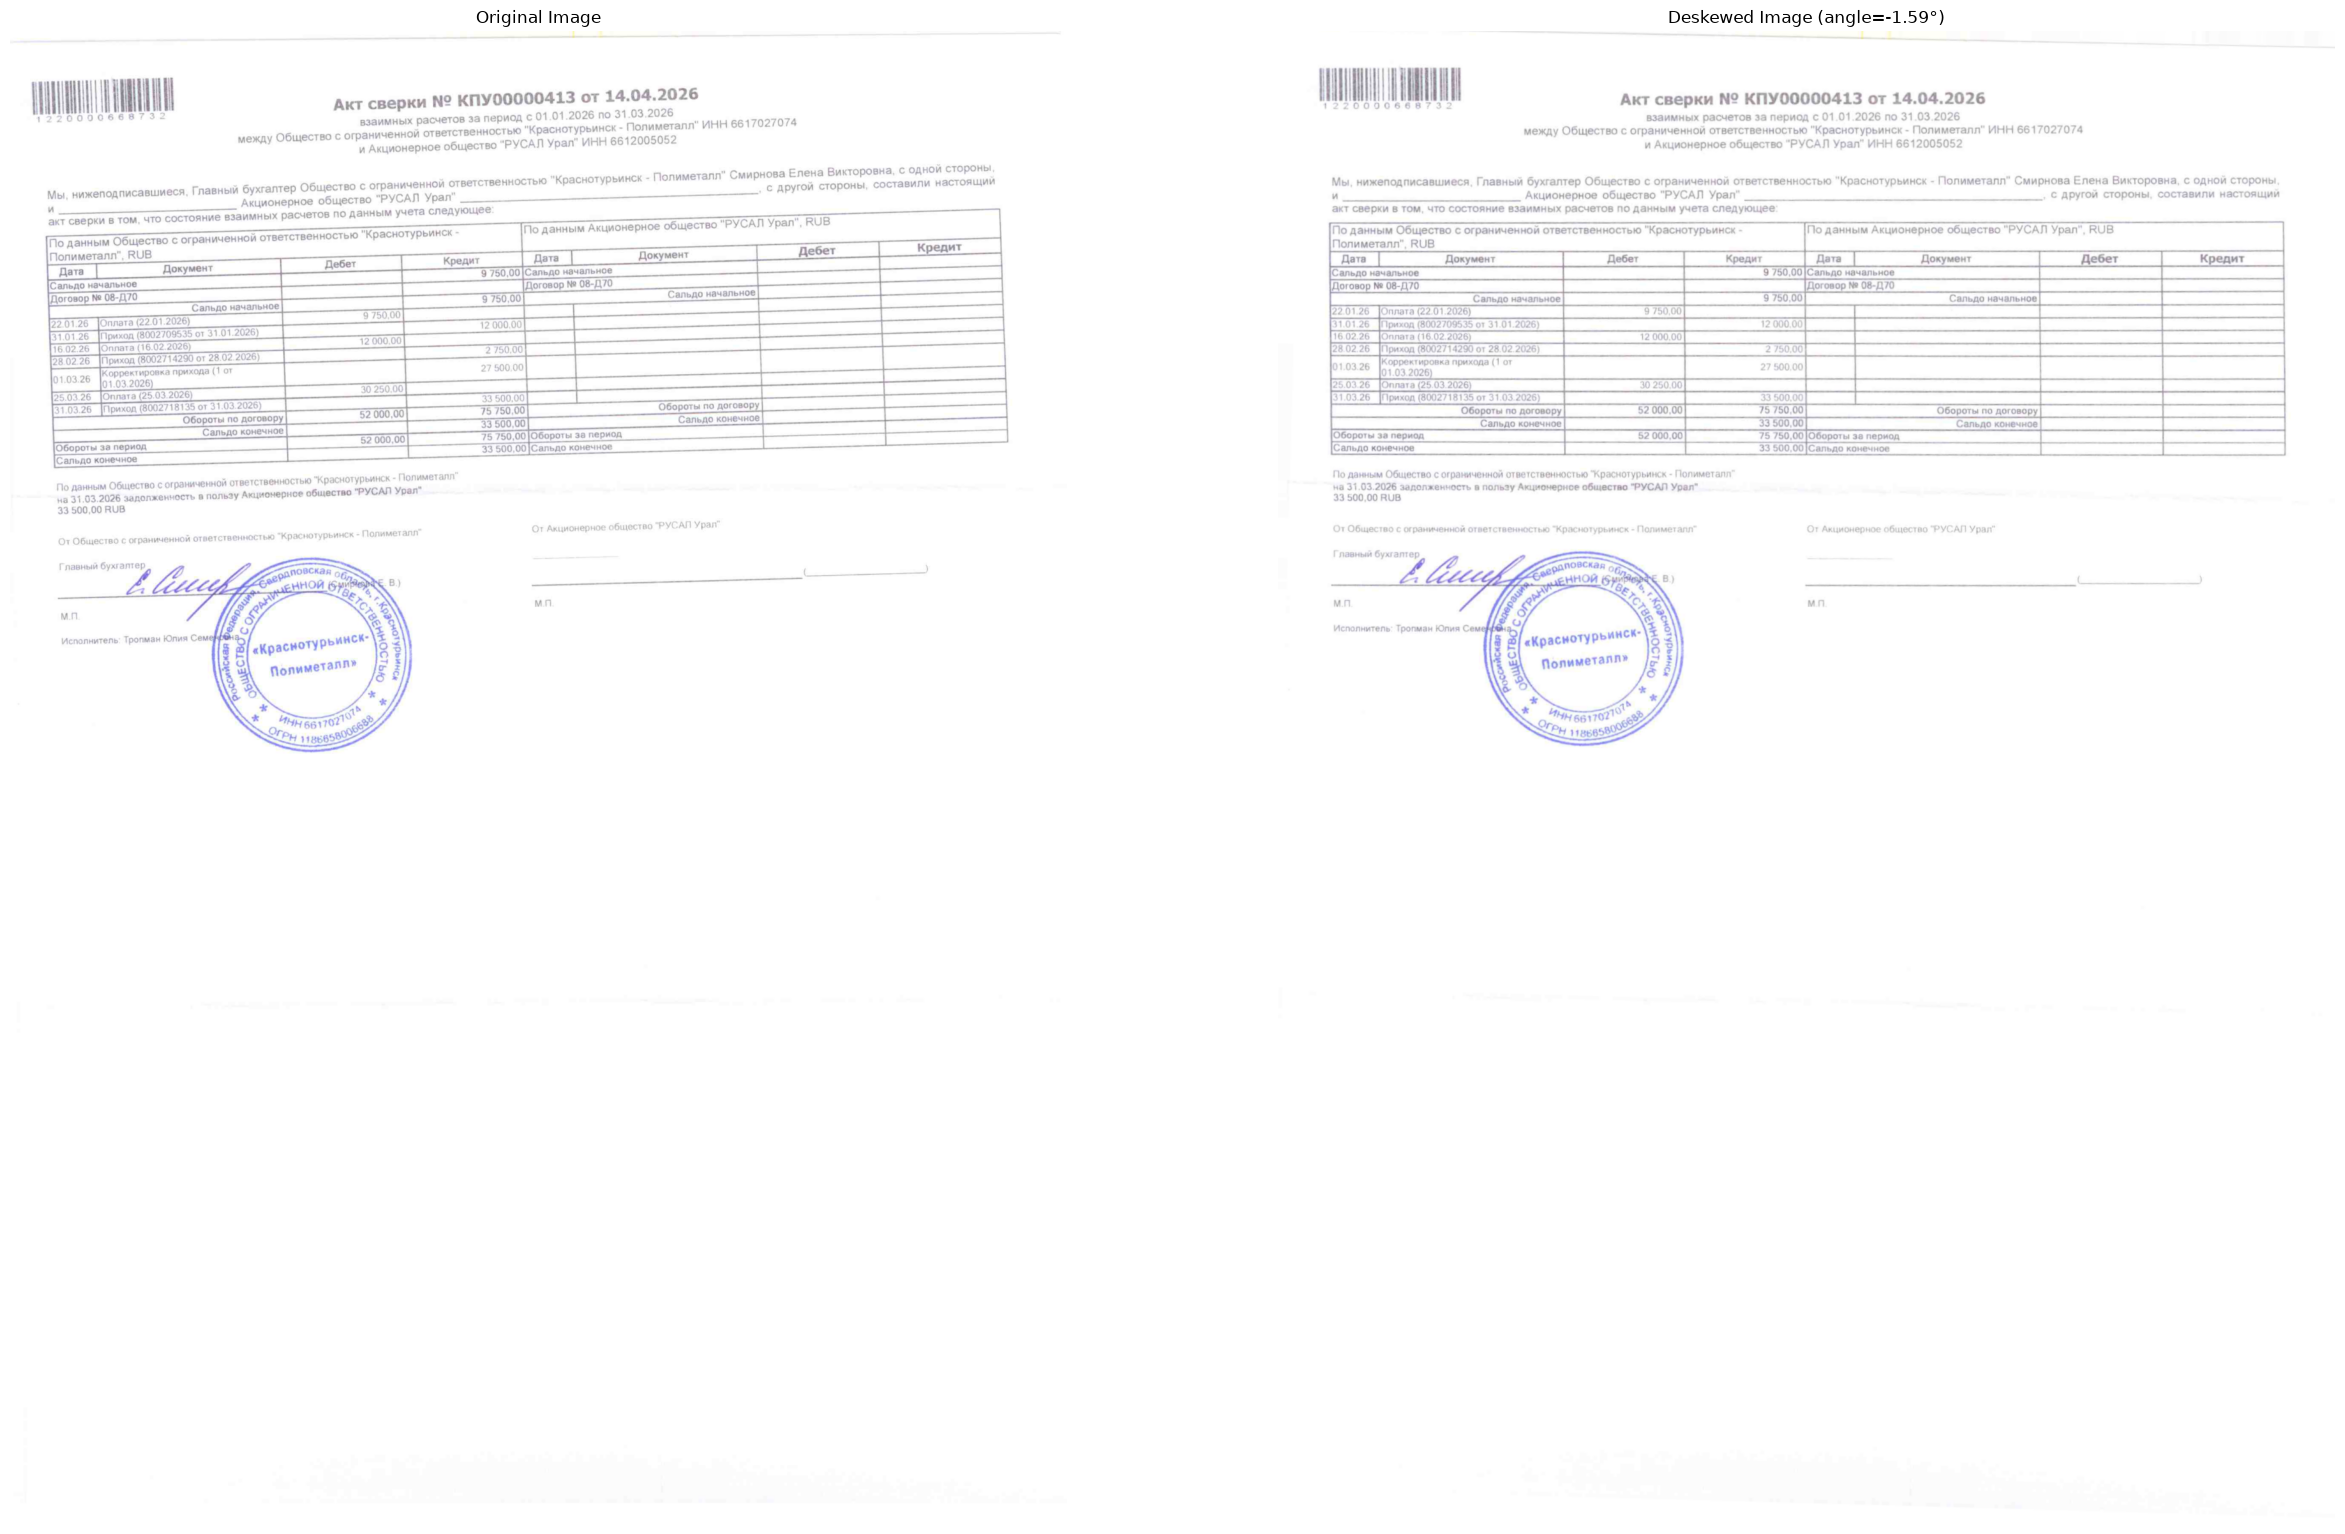

In [18]:
from vision_core.utils import image_utils

deskewed_img = image_utils.rotate_image(img, angle)

plt.figure(figsize=(30, 20))
plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title("Original Image")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(deskewed_img)
plt.title(f"Deskewed Image (angle={angle:.2f}°)")
plt.axis("off")
plt.show()
